# Detección de bordes

## Operadores de primera derivada

### Sobel
OpenCV tiene implementados algunos operadores de primera derivada como `Sobel` y `Scharr`. Los parámetros más importantes de ambas funciones son:

- Imagen de entrada
- Tipo de la imagen de salida (cv2.CV_64F es float)
- Orden de la derivada en x
- Orden de la derivada en y
- Tamaño del kernel (1, 3, 5 ó 7)

Así, con 1 y 0 en el tercer y cuarto parámetros, respectivamente, se calcula la derivada en *x* y con 0 y 1, la derivada en *y*.

/content
/content


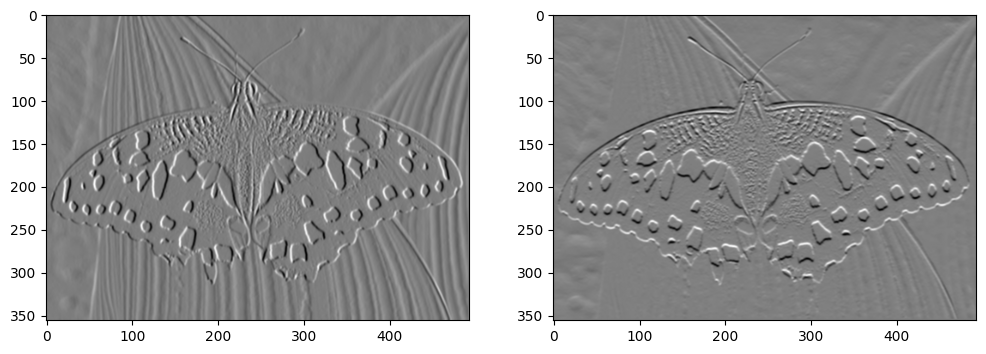

In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import cv2
!pwd
%cd /content
plt.rcParams["figure.figsize"] = [12,9]

im = cv2.imread('/content/drive/MyDrive/res/butterfly.jpg', cv2.IMREAD_GRAYSCALE)

sobelx = cv2.Sobel(im, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(im, cv2.CV_64F, 0, 1, ksize=5)

f, axarr = plt.subplots(1,2)
axarr[0].imshow(sobelx, cmap='gray')
axarr[1].imshow(sobely, cmap='gray')
plt.show()


Los bordes de las imágenes aparecen en blanco y negro mientras que las zonas sin borde aparecen en distintos tonos de gris. Esto sucede así porque matplot escala los valores obtenidos tras la convolución entre 0 (negro) y 1 (blanco).

Los valores mínimos y máximos de la derivada en x son:

In [ ]:
print ("Min", np.min(sobelx), "Max", np.max(sobelx))


Para obtener una imagen con fondo negro y los bordes marcados en blanco, podemos calcular el valor absoluto de la derivada:

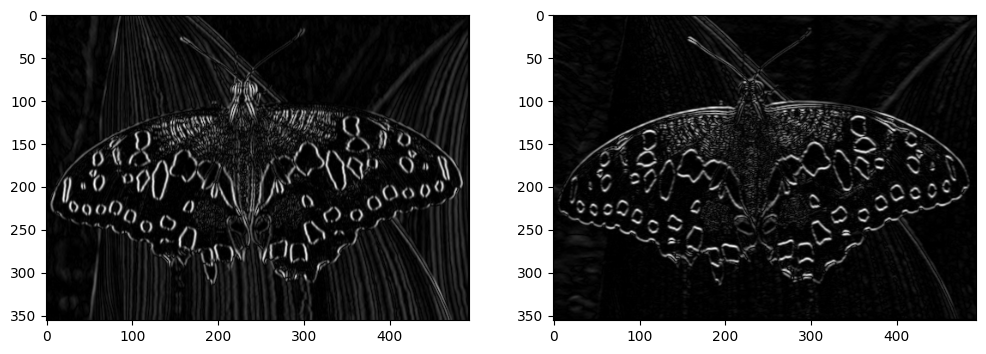

In [3]:
f, axarr = plt.subplots(1,2)
axarr[0].imshow(np.abs(sobelx), cmap='gray')
axarr[1].imshow(np.abs(sobely), cmap='gray')
plt.show()

Si queremos calcular los bordes, tenemos que combinar ambas derivadas. Tenemos dos opciones prácticamente equivalentes:

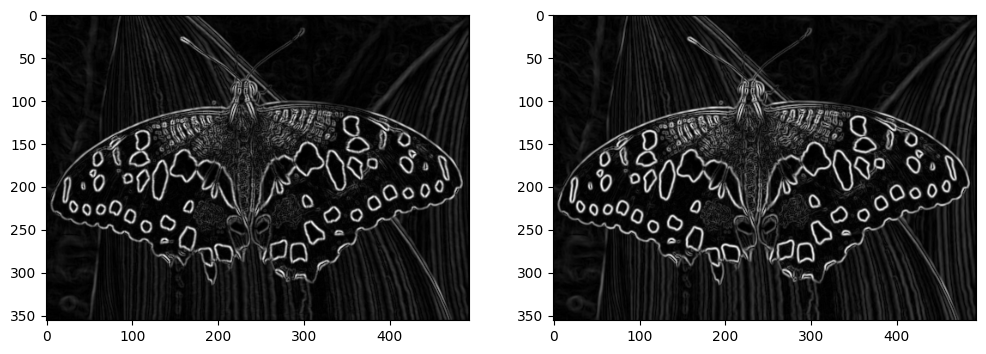

In [4]:
sobel1 = np.abs(sobelx) + np.abs(sobely)
sobel2 = np.sqrt(sobelx * sobelx + sobely * sobely)

f, axarr = plt.subplots(1,2)
axarr[0].imshow(sobel1, cmap='gray')
axarr[1].imshow(sobel2, cmap='gray')
plt.show()


### Ejercicio

Calcula los bordes de la imagen `im` utilizando kérneles de tamaño 3 y 7. Visualiza las imágenes de bordes. Calcula las diferencias entre las imágenes de bordes y visualiza los resultados. Que diferencias observas?


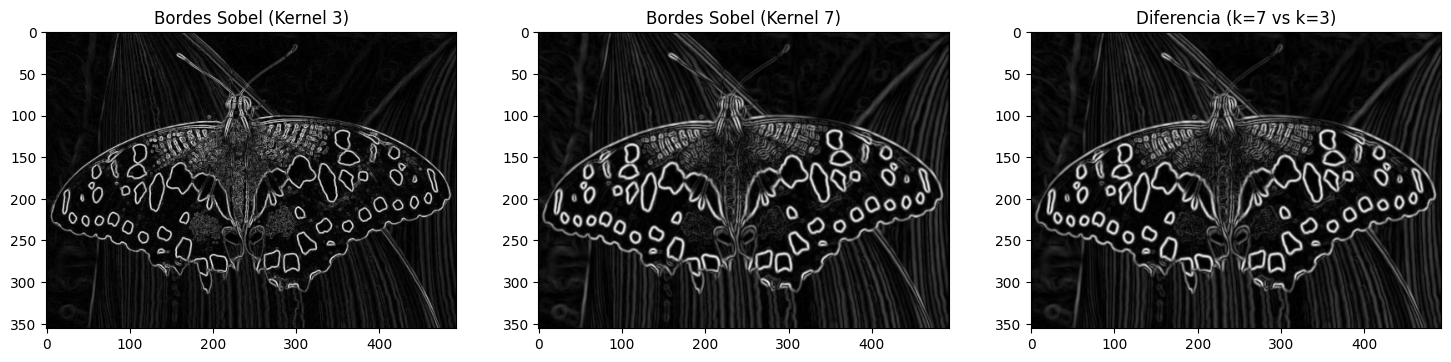

In [5]:
# Calcular derivadas en x e y con kernel 3
sobelx_3 = cv2.Sobel(im, cv2.CV_64F, 1, 0, ksize=3)
sobely_3 = cv2.Sobel(im, cv2.CV_64F, 0, 1, ksize=3)
sobel_3 = np.sqrt(sobelx_3**2 + sobely_3**2)

# Calcular derivadas en x e y con kernel 7
sobelx_7 = cv2.Sobel(im, cv2.CV_64F, 1, 0, ksize=7)
sobely_7 = cv2.Sobel(im, cv2.CV_64F, 0, 1, ksize=7)
sobel_7 = np.sqrt(sobelx_7**2 + sobely_7**2)

# Calcular la diferencia absoluta entre ambas imágenes de bordes
diferencia = np.abs(sobel_7 - sobel_3)

# Visualización
f, axarr = plt.subplots(1, 3, figsize=(18, 6))
axarr[0].imshow(sobel_3, cmap='gray')
axarr[0].set_title('Bordes Sobel (Kernel 3)')
axarr[1].imshow(sobel_7, cmap='gray')
axarr[1].set_title('Bordes Sobel (Kernel 7)')
axarr[2].imshow(diferencia, cmap='gray')
axarr[2].set_title('Diferencia (k=7 vs k=3)')
plt.show()

### Otros operadores de primera derivada

Podemos aplicar cualquier operador de primera derivada a una imagen utilizando la función genérica `filter2D` y una matriz con el kernel correspondiente.

[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]


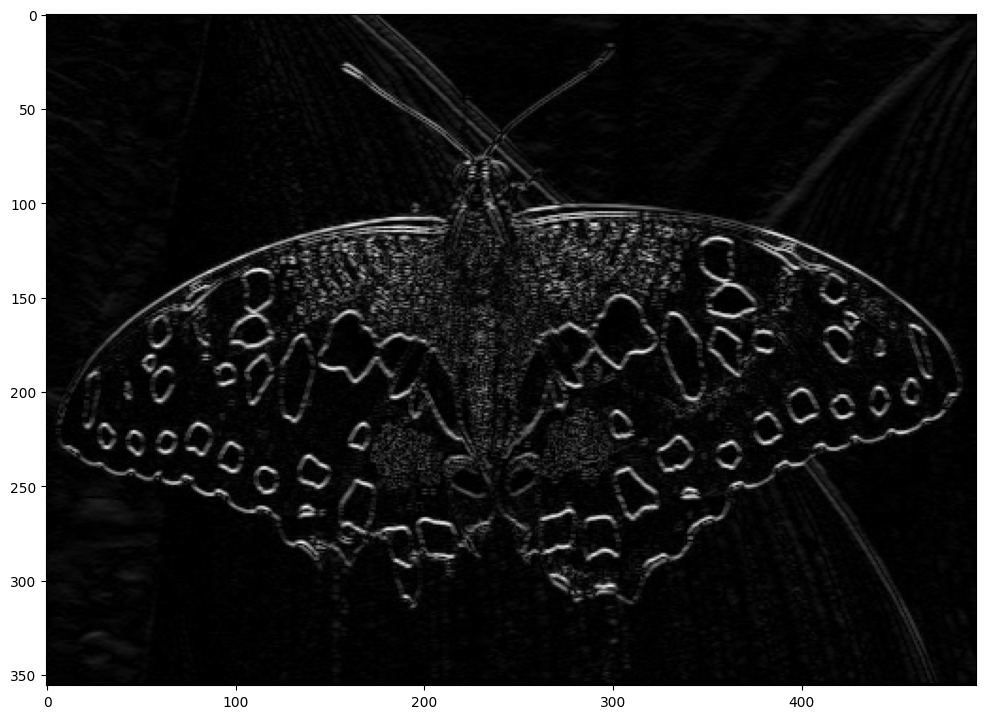

In [6]:
k_x = np.array([ [-1, -1, -1], [0,0,0], [1,1,1] ], dtype=float)

prewittx = cv2.filter2D(im, cv2.CV_64F, k_x)

plt.imshow(np.abs(prewittx), cmap='gray')
plt.plot()

print(k_x.transpose())

### Ejercicio
Calcula la derivada en y utilizando el kernel de Prewitt. Obtén la imagen de bordes combinando ambas derivadas. *Hint*: puedes usar la función `transpose` para obtener la matriz transpuesta del kernel.

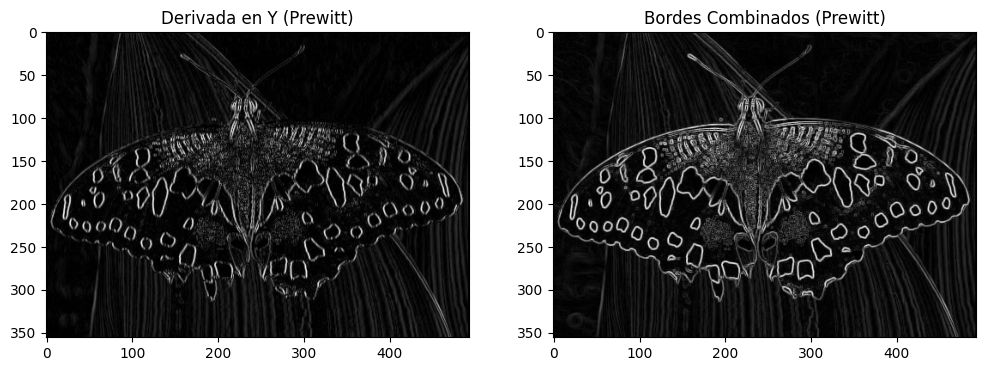

In [7]:
prewitt_kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

# Escribe aquí tu código
# Utilizamos la función transpose() sobre el kernel de X para obtener el de Y
k_y = k_x.transpose()

# Calculamos la derivada en Y
prewitty = cv2.filter2D(im, cv2.CV_64F, k_y)

# Combinamos ambas derivadas (asumiendo que prewittx ya fue calculado en la celda anterior)
prewitt_edges = np.sqrt(prewittx**2 + prewitty**2)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))
axarr[0].imshow(np.abs(prewitty), cmap='gray')
axarr[0].set_title('Derivada en Y (Prewitt)')
axarr[1].imshow(prewitt_edges, cmap='gray')
axarr[1].set_title('Bordes Combinados (Prewitt)')
plt.show()

## Operadores de segunda derivada
### Laplaciano

En OpenCV la función Laplacian  calcula el operador Laplaciano.

El tercer parámetro de la función indica le tamaño del kernel. Si este valor es 1, el operador se calcula utilizando el kernel [[0 1 0] [1 -4 1] [0 1 0] mientras que si es un número impar superior a 1, el laplaciano se calcula sumando las segundas derivadas en x e y calculadas con Sobel.

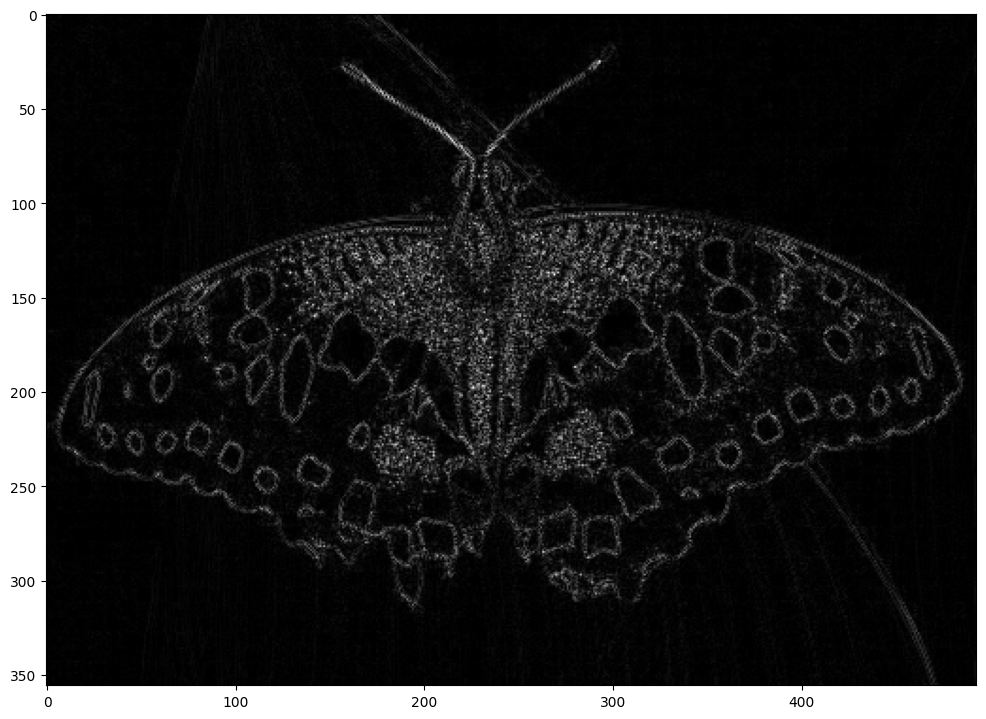

In [8]:
laplacian = cv2.Laplacian(im, cv2.CV_64F, ksize=1)


plt.imshow(np.abs(laplacian), cmap='gray')
plt.show()


### Ejercicio

Compara la salida del Laplaciano utilizando tamaños de kernel 3 y 7.

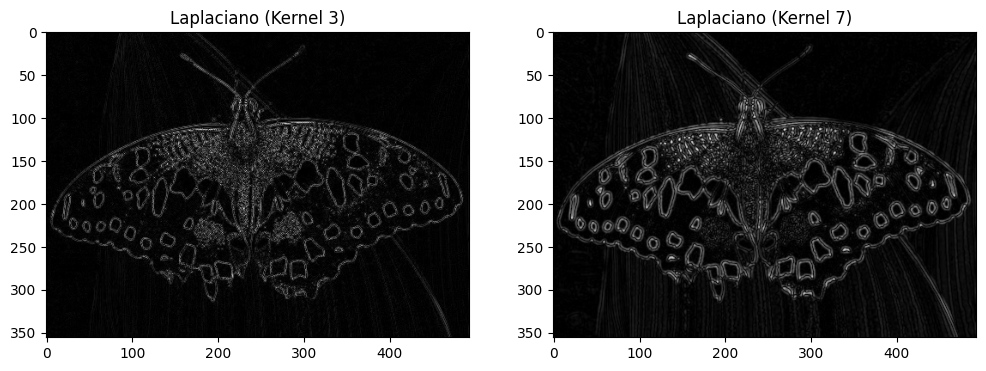

In [9]:
# Calcular el Laplaciano con tamaños de kernel 3 y 7
laplacian_3 = cv2.Laplacian(im, cv2.CV_64F, ksize=3)
laplacian_7 = cv2.Laplacian(im, cv2.CV_64F, ksize=7)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))
axarr[0].imshow(np.abs(laplacian_3), cmap='gray')
axarr[0].set_title('Laplaciano (Kernel 3)')
axarr[1].imshow(np.abs(laplacian_7), cmap='gray')
axarr[1].set_title('Laplaciano (Kernel 7)')
plt.show()

### LoG y DoG
Los algoritmos LoG y DoG no están implementados como funciones en OpenCV pero son muy sencillos de implementar combinando una serie de funciones.

Por ejemplo, para implementar el algoritmo LoG sólo necesitamos calcular un kernel gaussiano, convolucionarlo con la imagen y posteriormente aplicar el operador Laplaciano.


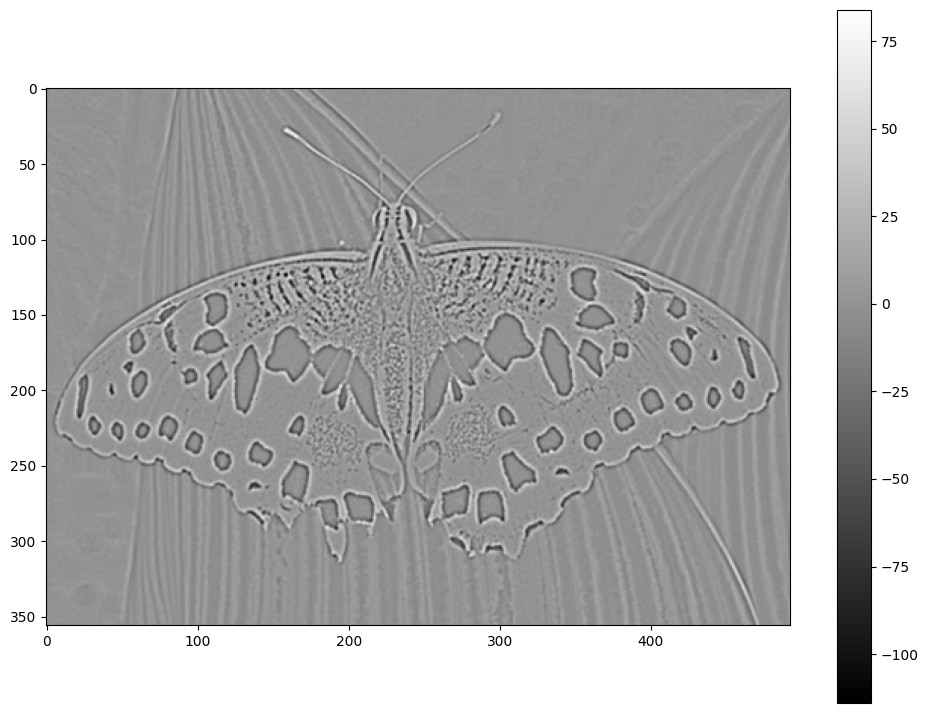

In [10]:


def laplacian_of_gaussian(image, sigma):
    """
    Applies a Gaussian kernel to an image and the Laplacian afterwards using OpenCV.
    """
    ksize = int(6 * sigma + 1)

    blurred = cv2.GaussianBlur(image, (ksize, ksize), sigma)

    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

    return laplacian

log_image1 = laplacian_of_gaussian(im, sigma=1)

plt.imshow(log_image1, cmap='gray')
plt.colorbar()
plt.show()


Por ejemplo, para implementar el algoritmo DoG sólo necesitamos calcular dos kérneles gaussianos con distintas desviaciones típicas, convolucionarlos con la imagen de entrada y restar las imágenes resultantes.

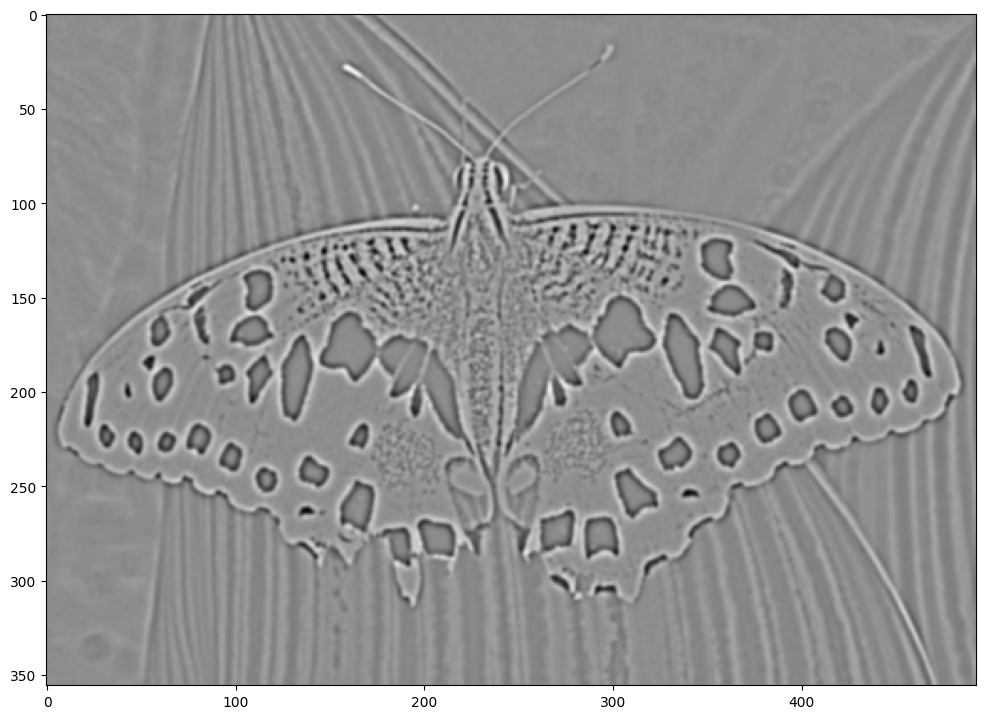

In [11]:
k1 = cv2.getGaussianKernel(15, 1, cv2.CV_64F) # tamaño kernel, desviación típica, tipo matriz de salida
k2 = cv2.getGaussianKernel(15, 2, cv2.CV_64F)

dog = cv2.sepFilter2D(im, cv2.CV_64F, k2, k2) # imagen de entrada, tipo  imagen de salida, kernel por filas, kernel por columnas
dog -= cv2.sepFilter2D(im, cv2.CV_64F, k1, k1)
plt.imshow(dog, cmap='gray')
plt.show()

Nota: el kernel gaussiano es separable, esto es, es posible construir un kernel 2D multiplicando kernels 1D. Por ello, la función `getGaussianKernel` nos devuelve un kernel 1D y la función `sepFilter2D` nos permite aplicar los kérneles 1D a la imagen. Convolucionar dos kérneles 1D por filas y columnas es más eficiente que convolucionar un kérnel 2D.

Las operaciones anteriores son equivalentes a convolucionar la imagen con el siguiente kernel:

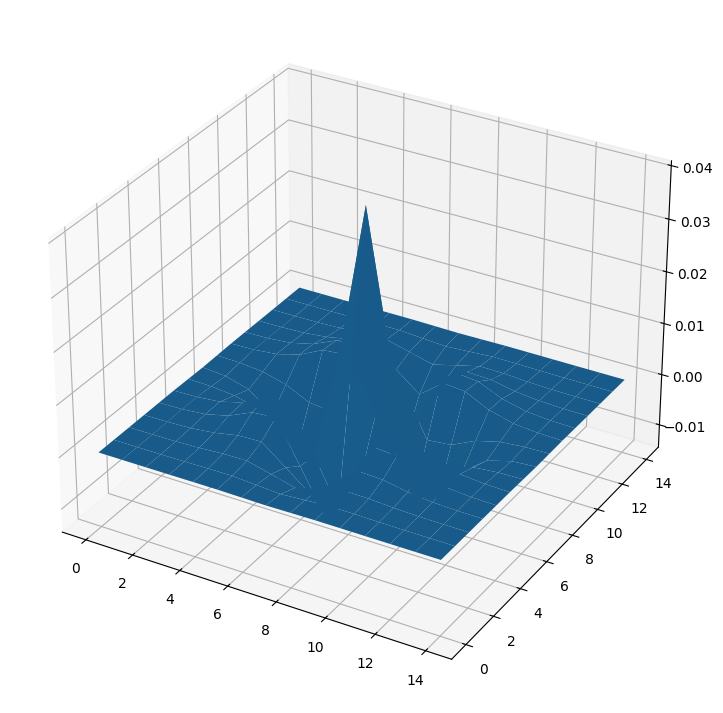

In [12]:
k = k2 - k1
k_2d = k * k.transpose()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')  # Crear un subplot 3D
x = np.arange(k_2d.shape[0])
y = np.arange(k_2d.shape[1])
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, k_2d)
plt.show()

Una vez que tenemos calculado el resultado de la convolución con la diferencia de gaussianas el siguiente paso es calcular los cruces por cero.

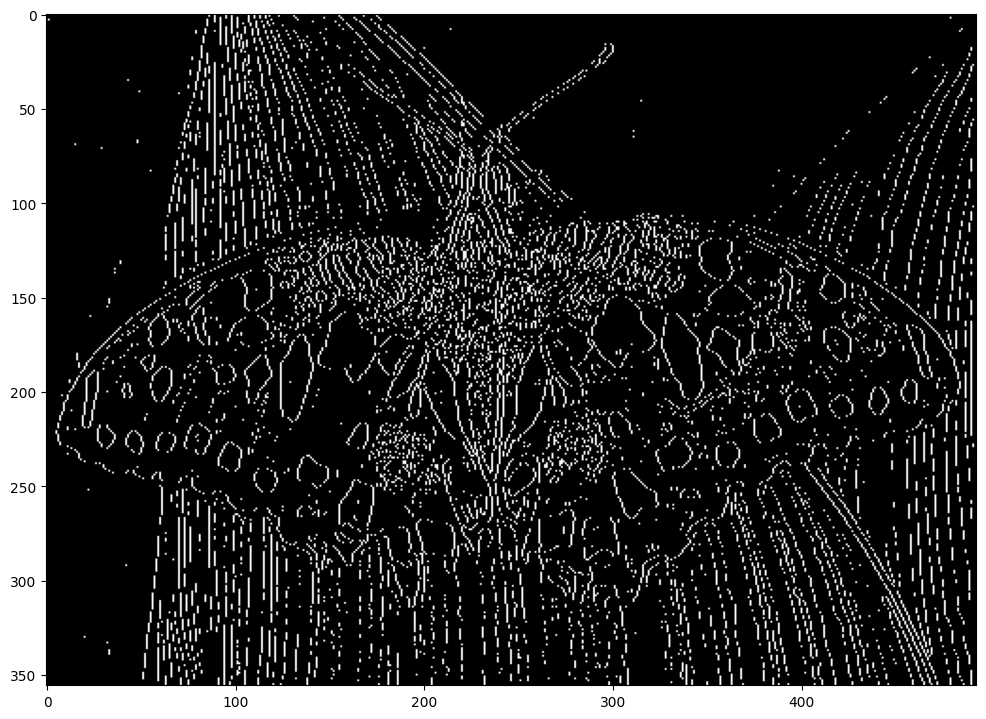

In [13]:
def zero_crossing(dog_output, thr):
    output = np.zeros(dog_output.shape, dog_output.dtype)
    over_thr = (np.abs(dog_output) >= thr)
    output[np.where(np.diff(np.sign(dog)))] = 1
    output *= over_thr
    return output

dog_zc = zero_crossing(dog, 2)
plt.imshow(dog_zc, cmap="gray")
plt.show()

### Ejercicio
Prueba el efecto que tiene en la imagen de bordes variar la desviación típica de cada una de las gaussianas. En cada caso ajusta el umbral de los cruces por cero para eliminar ruido.

Nota: el tamaño óptimo de un kernel gaussiano es un número impar superior a `2*np.ceil(3*sigma)`,

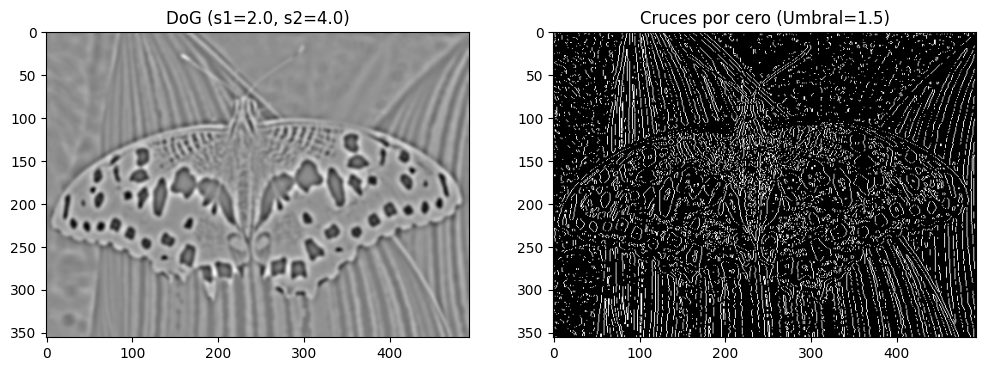

In [14]:
# Definimos nuevas desviaciones típicas
sigma1 = 2.0
sigma2 = 4.0

# Calculamos el tamaño óptimo del kernel (número impar > 2*np.ceil(3*sigma))
ksize_opt = int(2 * np.ceil(3 * max(sigma1, sigma2)) + 1)

# Obtenemos los kérneles gaussianos 1D
k1_new = cv2.getGaussianKernel(ksize_opt, sigma1, cv2.CV_64F)
k2_new = cv2.getGaussianKernel(ksize_opt, sigma2, cv2.CV_64F)

# Aplicamos los filtros
dog_new = cv2.sepFilter2D(im, cv2.CV_64F, k2_new, k2_new)
dog_new -= cv2.sepFilter2D(im, cv2.CV_64F, k1_new, k1_new)

# Calculamos los cruces por cero ajustando el umbral
umbral = 1.5  # Modifica este umbral para ver cómo afecta la eliminación de ruido
dog_zc_new = zero_crossing(dog_new, umbral)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))
axarr[0].imshow(dog_new, cmap='gray')
axarr[0].set_title(f'DoG (s1={sigma1}, s2={sigma2})')
axarr[1].imshow(dog_zc_new, cmap='gray')
axarr[1].set_title(f'Cruces por cero (Umbral={umbral})')
plt.show()

## Canny
El algoritmo de Canny está implementado en OpenCV. Se recomienda añadir un paso de suavizado previo para eliminar ruido y mejorar los resultados. Para realizar este suavizado se puede utilizar la función `blur`, que aplica un filtro de medias, `GaussianBlur` que aplica un suavizado gaussiano o bien la función genérica `filter2D` con un filtro de suavizado *ad hoc*.

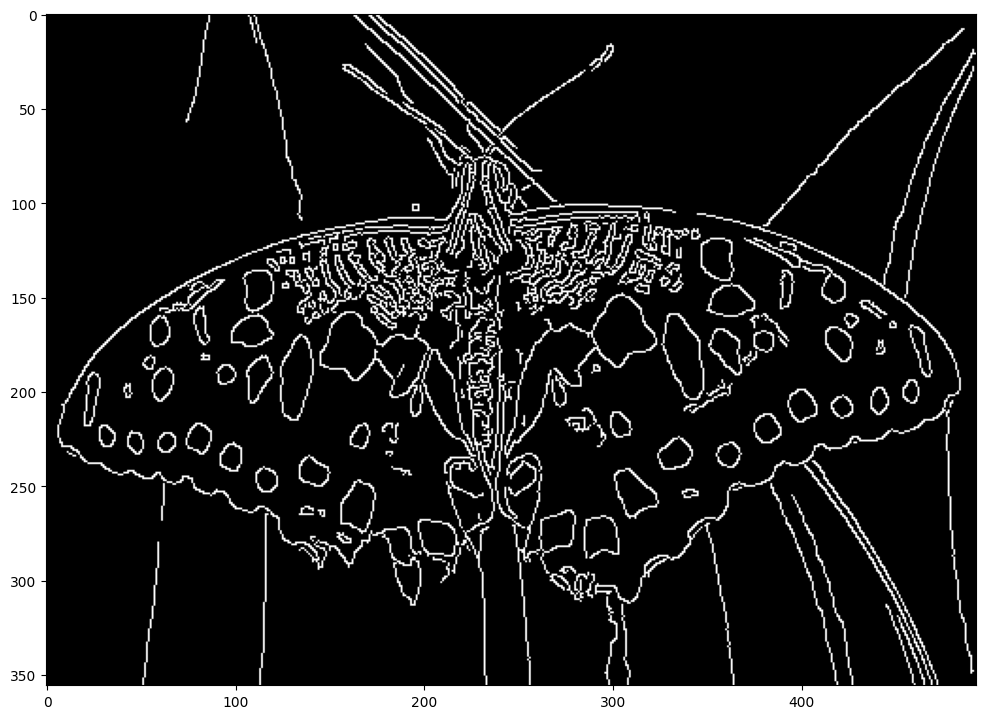

In [15]:

blurred = cv2.blur(im, (3,3)) # imagen de entrada, tamaño del kernel de suavizado
canny = cv2.Canny(blurred,100,200) # imagen de entrada, umbral mínimo y máximo utilizado en la histéresis

plt.imshow(canny, cmap='gray')
plt.show()

### Ejercicio
Compara la salida del filtro de Canny sin aplicar suavizado previo y aplicando un suavizado con un filtro de medias de 7x7. Ajusta en cada caso los umbrales de la umbralización por histéresis.

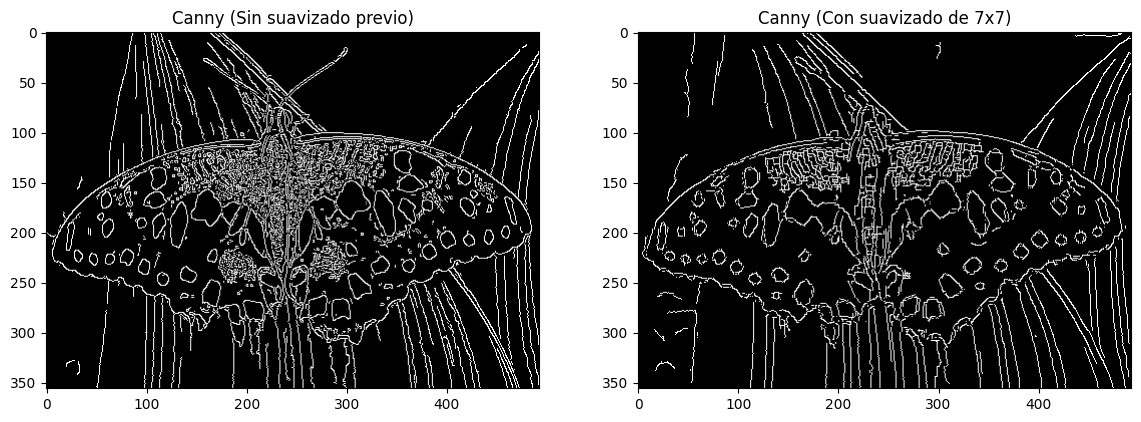

In [16]:
# Canny sin suavizado previo
canny_sin_suavizar = cv2.Canny(im, 100, 200)

# Aplicar suavizado con filtro de medias de 7x7
im_blurred_7x7 = cv2.blur(im, (7, 7))

# Canny sobre la imagen suavizada
# Nota: Al emborronar tanto la imagen, los gradientes caen,
# por lo que suele ser necesario bajar los umbrales de histéresis.
canny_suavizado = cv2.Canny(im_blurred_7x7, 30, 90)

f, axarr = plt.subplots(1, 2, figsize=(14, 7))
axarr[0].imshow(canny_sin_suavizar, cmap='gray')
axarr[0].set_title('Canny (Sin suavizado previo)')
axarr[1].imshow(canny_suavizado, cmap='gray')
axarr[1].set_title('Canny (Con suavizado de 7x7)')
plt.show()